# Prédiction de la druggabilité de poches protéiques

Les poches protéiques constituent les régions structurales susceptibles d'accueillir des ligands. Leur composition physicochimique, leur taille et leur géométrie peuvent être liées à leur capacité à fixer un candidat médicament, c'est-à-dire à leur druggabilité.

Dans ce projet on cherche à déterminer **si les descripteurs d'une poche ligand-based permettent de prédire sa druggabilité**.

- Autrices: Laurédane Coustillas, Farah-Luna Gonzalez, Anna Perova
- Étudiantes de M2 BI-ISDD - Modélisation des macromolécules
- Date: 21/09/2026 - 26/09/2026

- Étapes:
    1. Pré-processing & Analyse de dataset
    2. Clustering
    3. Bootstrap
    4. CART pour minimiser l'erreur
    5. RF et Gradiant Boosting
    6. PLS ou PLSDA

- Info sur dataset:
    - L'ensemble de données a été extrait du jeu de données de Krasowski et contient 400 poches :
        - 316 poches druggables,
        - 84 poches moins druggables.

Decrit selon 19 variables:
-   descripteurs quantitatifs de la géométrie de la poche: `hydrophobic_kyte`, `p_hydrophobic_residue`, `p_polar_residues`, `p_aromatic_residues`, `p_aliphatic_residues`, `p_Otyr_atom`,  `p_NE2_atom`, `p_Nlys_atom`, `p_Ntrp_atom`, `p_Ooh_atom`, `p_ND1_atom`,  `SURFACE_HULL`, `DIAMETER_HULL`, `VOLUME_HULL`, `SMALLEST_SIZE`,  `RADIUS_CYLINDER`, `C_RESIDUES`, `NumAtoms_atm`, `Radius_of_gyration_atm`;
-   descripteurs qualitatif: `Shape` (4 types/facteurs: Sphere, Disk, Strongly anisotropic, Rod) d'après *Ziani et al., 2026*;

Variables à prédire: 
-   Druggabilité (qualitative) = le type de druggabilité de chaque poche : 1 = druggable, 0 = moins druggable (Col 24);
-   Score_Drugg (quantitative) = score de druggabilité (Col 3).


- Packages utilisés:
    - `FactoMineR`,
    - `factoextra`,
    - `corrplot`,
    - `gplots`,
    - `pheatmap`,
    - `caret`,
    - `pROC`,
    - `fmsb`,
    - `rpart`,
    - `MASS`,
    -`rpart.plot`,
    - `randomForest`, 
    - `dplyr`


### Partie 0. Préparation

#### 1. Intallation des packages et chargement du dataset

In [2]:
required_packages <- c("FactoMineR","factoextra","corrplot","gplots",
"pheatmap","caret","pROC","fmsb","rpart","MASS","rpart.plot","randomForest", "dplyr")
lapply(required_packages, require, character.only = TRUE)

file <- read.csv("data.csv")
glimpse(file)
dim(file)
# Vérifier si les NA sont présents
file_na <- na.omit(file)
dim(file_na)
# Transformer la variable `Shape` en factor
file_na$Shape <- as.factor(file_na$Shape)

Loading required package: FactoMineR
Loading required package: factoextra
Loading required package: ggplot2
Welcome to factoextra!
Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods
Loading required package: corrplot
corrplot 0.95 loaded
Loading required package: gplots

---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------


Attaching package: ‘gplots’

The following object is masked from ‘package:stats’:

    lowess

Loading required package: pheatmap
Loading required package: caret
Loading required package: lattice
Loading required package: pROC
Type 'citation("pROC")' for a citation.

Attaching package: 

#### 2. Ajouter la variable à prédire : Druggabilité 
- Si `Score_Drugg` > 0.5 -> "Druggable"
- Sinon: "Non-Druggable"

In [3]:
file_na$druggable <- if_else(file$Score_Drugg > 0.5, "Druggable", "Non-Druggable")

#### 3. Mise à l'échelle
- Énlèver la variable `Score_Drugg`et autres variables non-numeriques pour mettre les numeriques à l'échelle
- Faire un plot avant/après pour comparer

In [4]:
file_wo_drug <- file_na[-3]
data <- file_na[4:22]
data_raw <- data
data_s <- as.data.frame(scale(data))

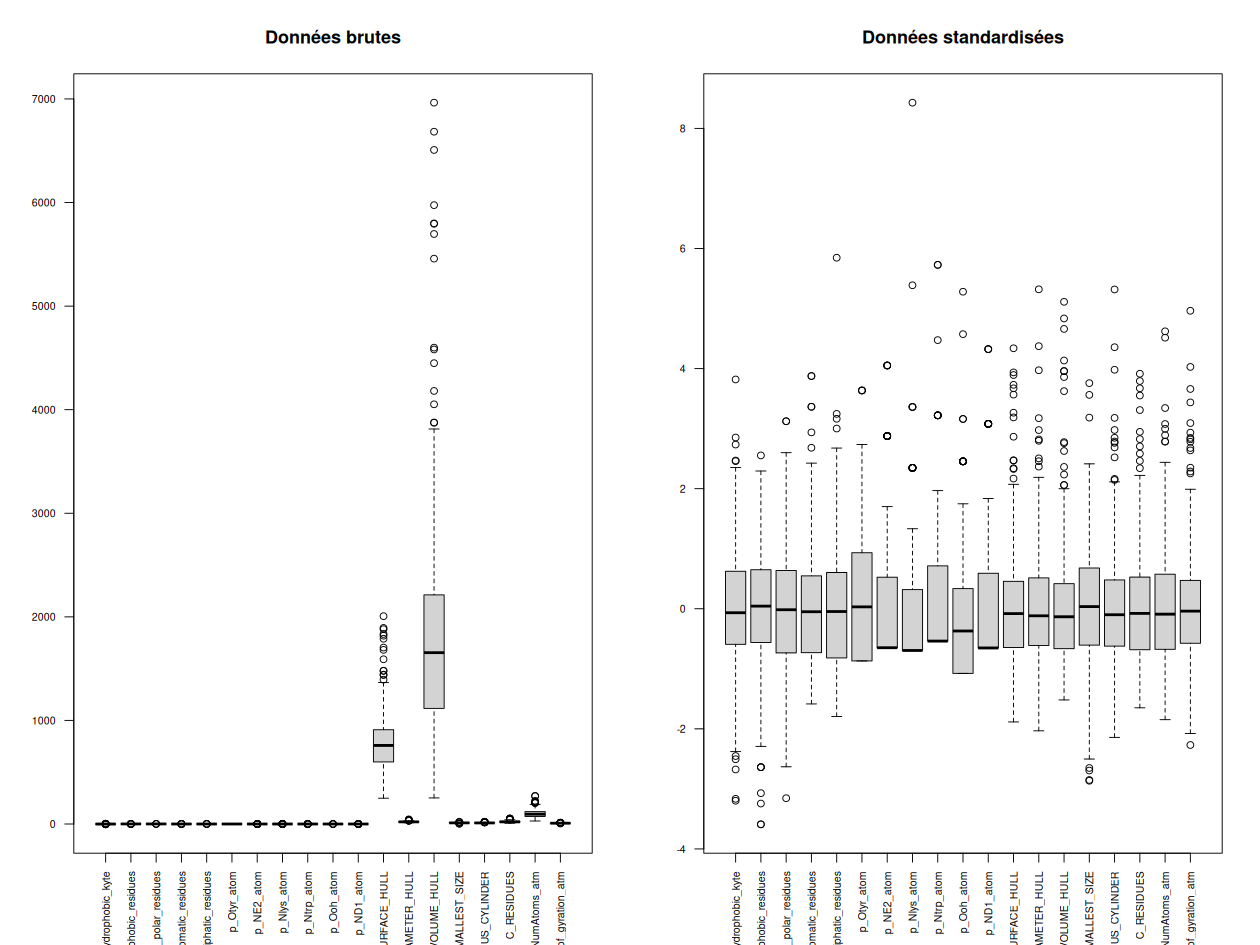

In [5]:
par(mfrow = c(1, 2))
boxplot(data_raw, main = "Données brutes", las = 2, cex.axis = 0.7)
data_s <- as.data.frame(scale(data))
boxplot(data_s, main = "Données standardisées", las = 2, cex.axis = 0.7)
par(mfrow = c(1, 1))

*Observations: `SURFACE_HULL` et `VOLUME_HULL` sont les plus importants due à la difference des unités avec le reste des variables; Le `scale()` permet de tous normaliser. On note un outlier pour `p_Nlys_atom`, c'est possible qu'il faut l'énlever.*

#### 4. Vérification de correlations entre le variables & Plot la matrice de correlations

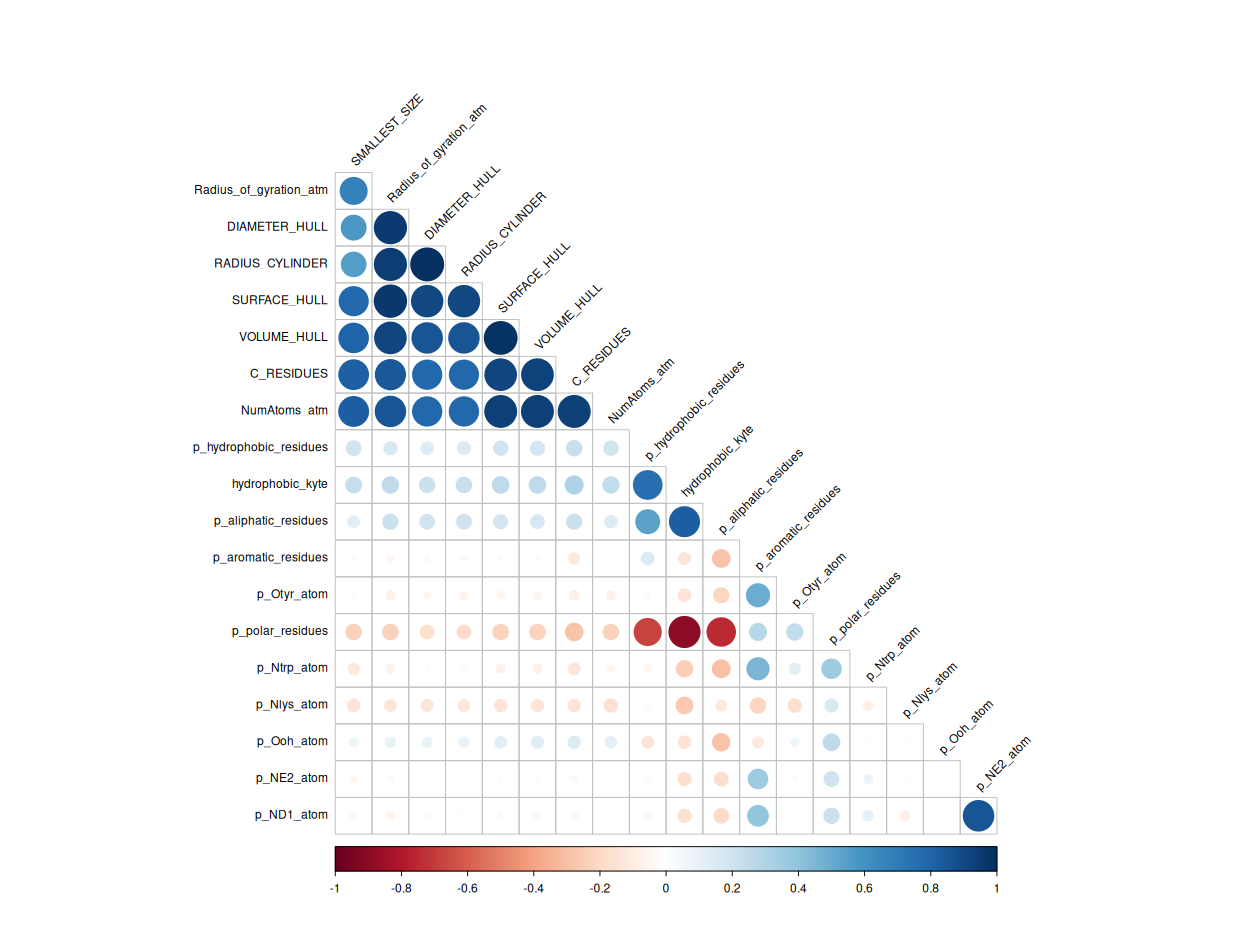

In [6]:
corr_matrix <- cor(data_s)
corrplot(corr_matrix, 
         method = "circle",     
         type = "lower",        
         order = "hclust",      
         tl.col = "black",      
         tl.srt = 45,           
         tl.cex = 0.8,          
         diag = FALSE)


#### 5. Vérifier si les variances sont proches à zero

In [7]:
nearZeroVar(data_s, saveMetrics = TRUE)

                       freqRatio percentUnique zeroVar
hydrophobic_kyte        1.200000         59.75   FALSE
p_hydrophobic_residues  1.130435         14.25   FALSE
p_polar_residues        1.933333         17.25   FALSE
p_aromatic_residues     1.526316         12.25   FALSE
p_aliphatic_residues    1.263158         12.50   FALSE
p_Otyr_atom             1.395161          1.50   FALSE
p_NE2_atom              2.525253          1.25   FALSE
p_Nlys_atom             1.887931          1.75   FALSE
p_Ntrp_atom             3.958333          1.50   FALSE
p_Ooh_atom              1.130841          2.25   FALSE
p_ND1_atom              2.436893          1.25   FALSE
SURFACE_HULL            2.000000         99.75   FALSE
DIAMETER_HULL           1.000000         86.75   FALSE
VOLUME_HULL             1.000000        100.00   FALSE
SMALLEST_SIZE           1.000000         77.00   FALSE
RADIUS_CYLINDER         1.333333         78.75   FALSE
C_RESIDUES              1.000000         11.00   FALSE
NumAtoms_a


### Partie 1. Analyse Non-Supervisée (Clustering)

Deux méthodes de classification etudié:

- classification hiérarchique
- kmeans

#### Classification Ascendante Hiérarchique (CAH)

Functions used here: 
 - `scale()` = normalization of data
 - `dist()` = distance matrix calculation
 - `hclust()` = calculation of the classification tree 
 - `plot()` = graphical representation of the classification tree
 - `fviz_nbclust`(factoextra) = determination of the optimal number of clusters according to a chosen criterion
 - `rect.hclust()` = visualization of clusters on the classification tree
 - `cutree()` = cluster retrieval

In [8]:
#on scaled data! (without drugg col)
#dist() function!
dts.euc <- dist(data_s, method = "euclidean")

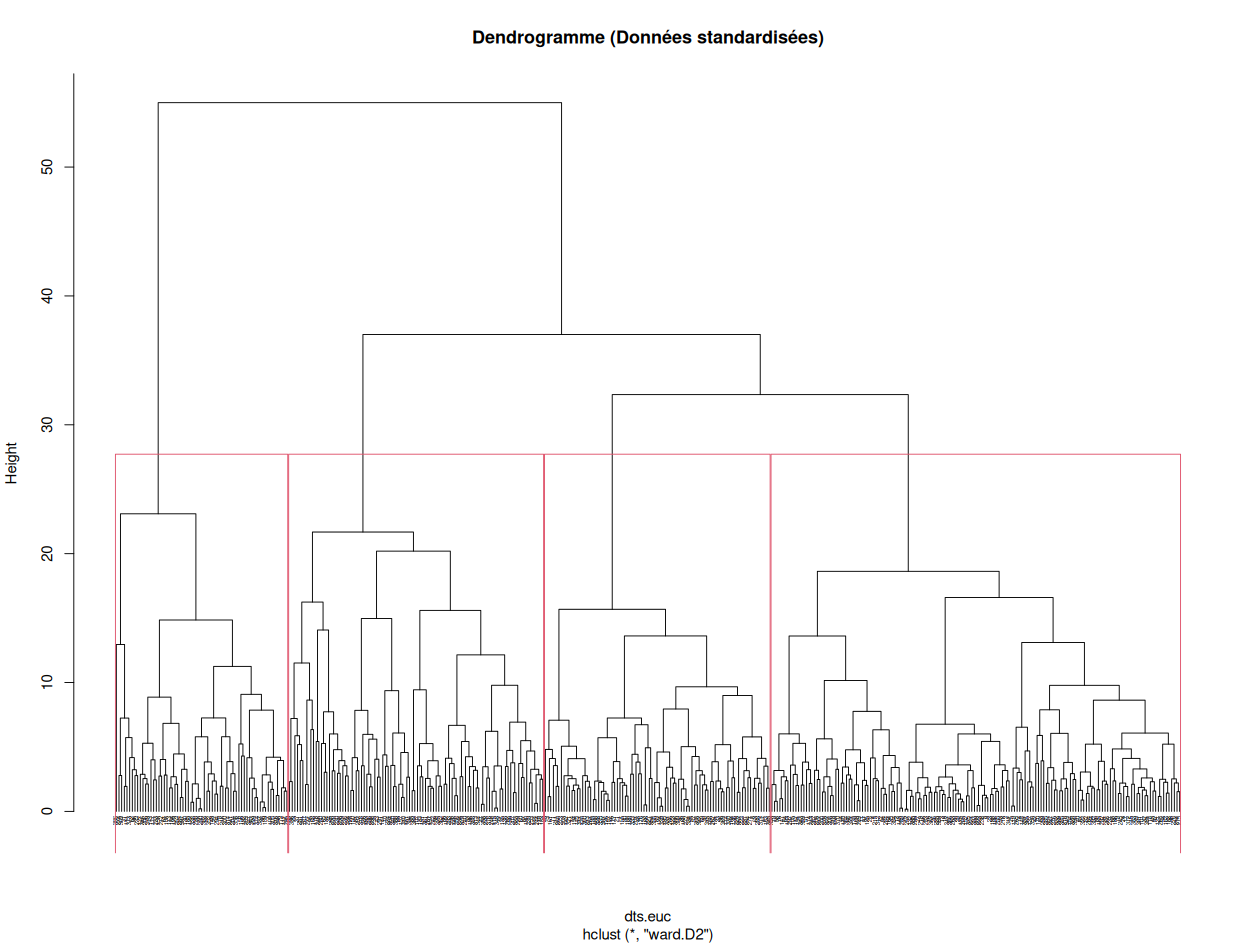

In [9]:
#we use scaled data; wardD2 method = minimizes the intra variability of the clusters and maximizes the inter variability (between clusters)

data_s_hca <- hclust(dts.euc, method = "ward.D2")

#plot the dendrogram
plot(data_s_hca, hang = -1, cex = 0.4, main = "Dendrogramme (Données standardisées)")
rect.hclust(data_s_hca, k = 4)


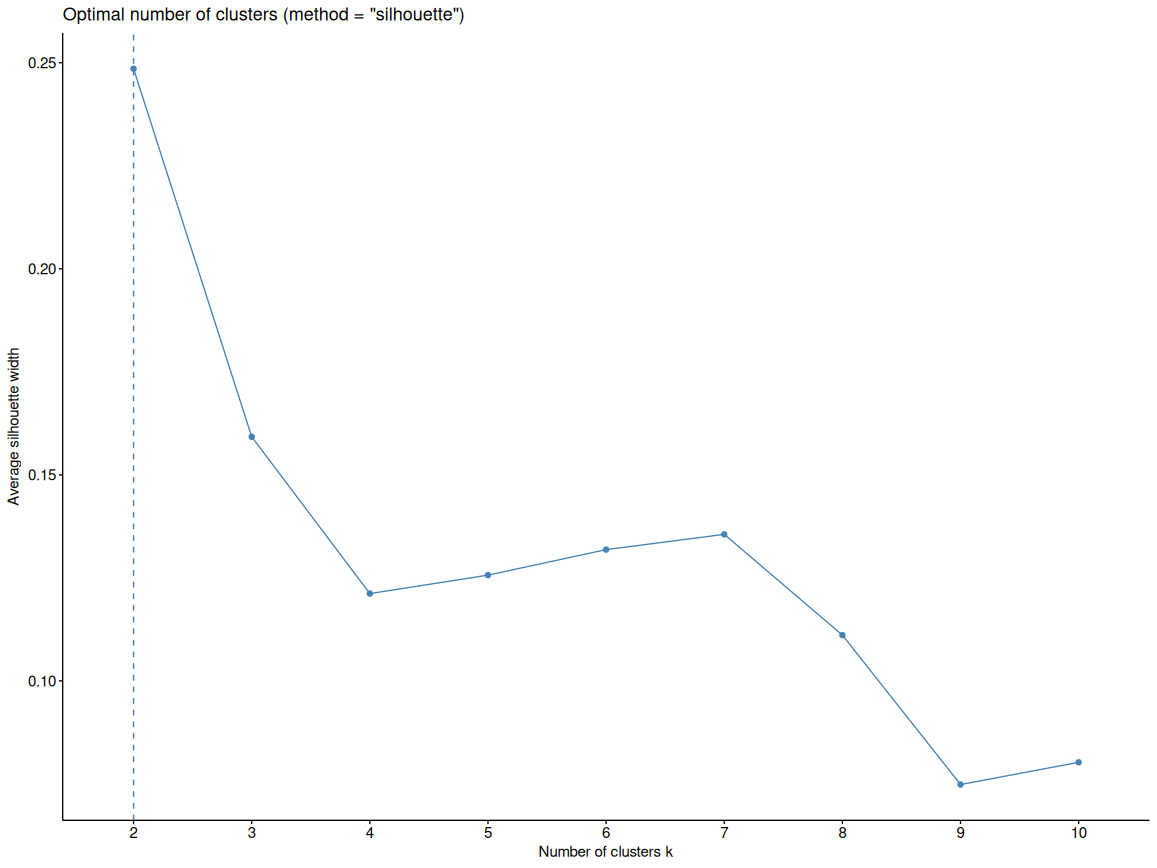

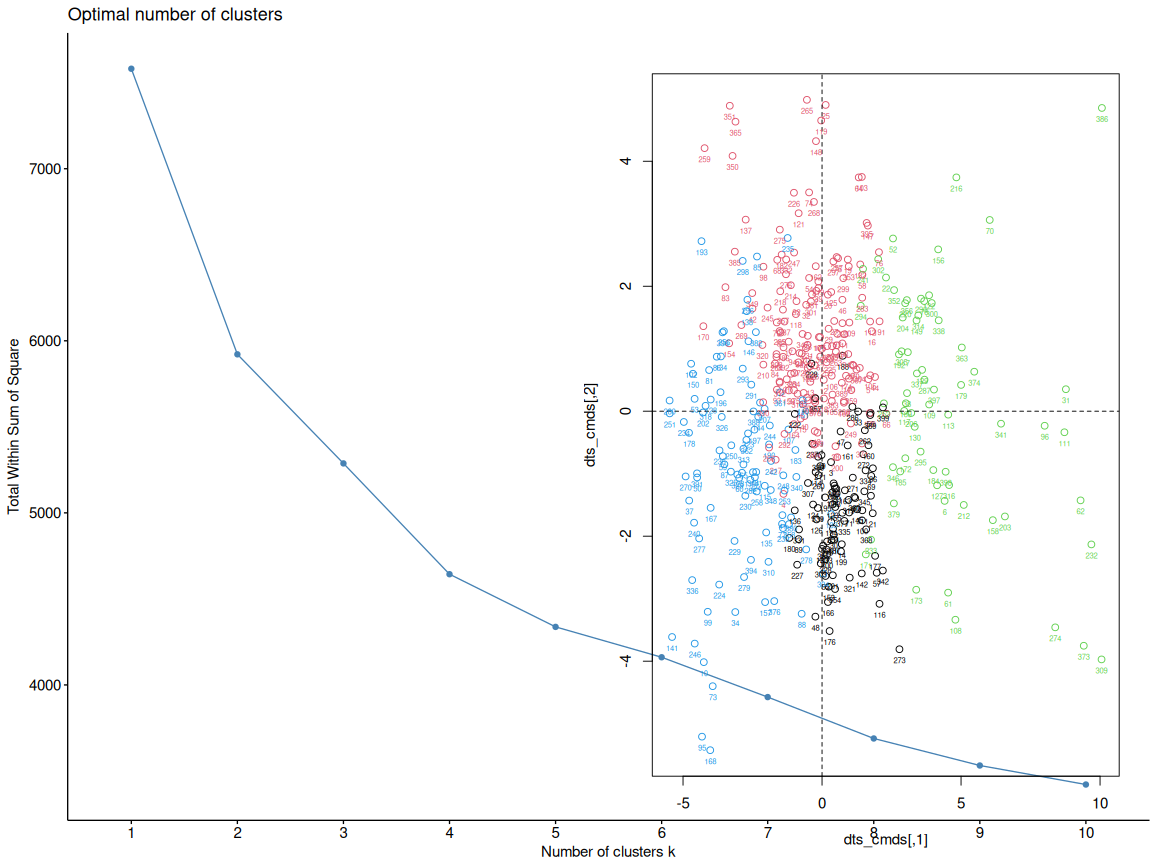

In [27]:
fviz_nbclust(data_s,
             hcut,
             method = "silhouette")

fviz_nbclust(data_s, kmeans, method="wss")
#takes into argument the data (not the dist matrx)
#observes the evolution of intra-cluster variability as a function of the number of clusters to determine the optimal number of clusters
#FUNcluster option = hcut

*Quel nombre de cluster allez-vous choisir ? Pourquoi ?*

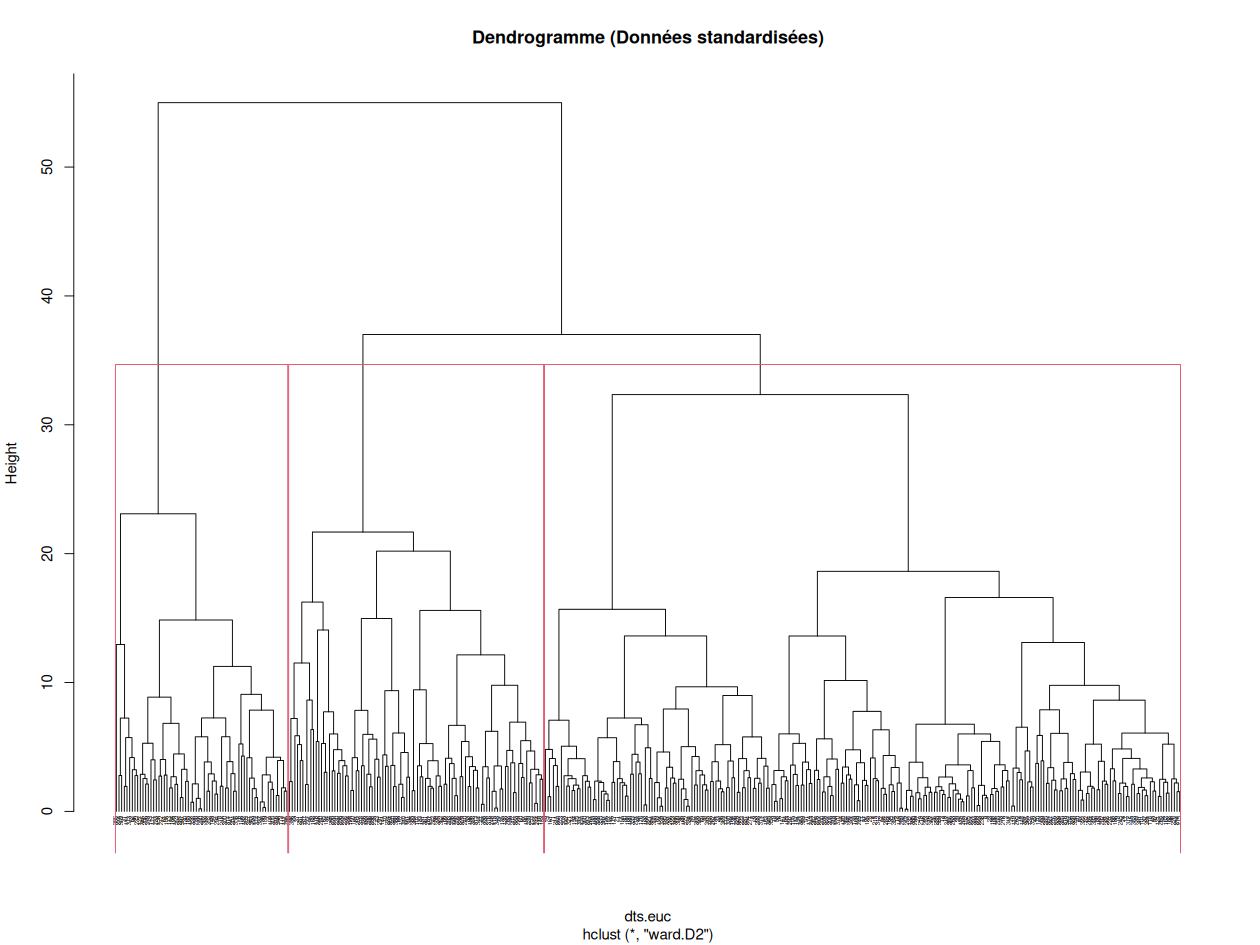

In [ ]:
#rect.hclust = adds the rectangular boxes that selec the clusters on the dendrogram
plot(data_s_hca, hang = -1, cex = 0.4, main = "Dendrogramme (Données standardisées)")
rect.hclust(data_s_hca, k = 3)

In [15]:
#cutree() function!
#retrieves for each individual (protein pockets) their cluster
group_hclust <- factor(cutree(data_s_hca, k = 3))
table(group_hclust)

group_hclust
  1   2   3 
239  65  96 

In [28]:
dts.cluster <- cutree(data_s_hca, k = 4)
dts_cmds <- cmdscale(dts.euc)

plot(dts_cmds, col = dts.cluster) + 
abline(h = 0, v = 0, lty = 2) +
text(dts_cmds, labels = rownames(data_s), cex = 0.5, pos = 1, col = dts.cluster)


integer(0)

In [ ]:
library(fpc)
clusterboot(data_s_cluster, nc=4, B=1000,)

: [1m[33mError[39m in `clustermethod()`:[22m
[33m![39m argument "clustermethod" is missing, with no default

In [ ]:
# Split Train/Test
sample_idx <- sample(1:nrow(data), size = nrow(data_s)*0.7)
train_set <- data_clean[sample_idx, ]
test_set <- data_clean[-sample_idx, ]
